<a href="https://colab.research.google.com/github/chrishg23-jpg/Community-Development-Framework/blob/main/ESO003b.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# HES EOS + dynamic species toy universe

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (6, 6)
plt.rcParams["image.cmap"] = "magma"


In [ ]:
# Lattice size
N = 128

# Time stepping
dt = 0.01
n_steps = 2000
output_every = 200

# Environment parameters
env_ring_radius = 0.35
env_ring_width  = 0.05
env_basin_radius = 0.15
env_basin_depth  = -1.0
env_background_slope = 0.3

# Species parameters (will be used in registry)


In [ ]:
# Normalized coordinates in [-1, 1] x [-1, 1]
x = np.linspace(-1.0, 1.0, N)
y = np.linspace(-1.0, 1.0, N)
X, Y = np.meshgrid(x, y, indexing="ij")

R = np.sqrt(X**2 + Y**2)


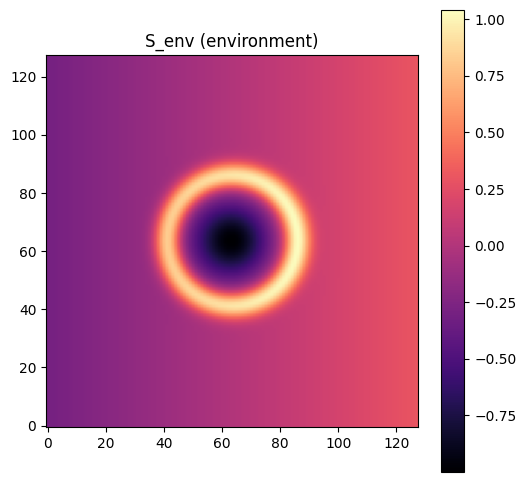

In [ ]:
def build_environment(X, Y, R):
    # Outer ring (positive entropic ridge)
    ring = np.exp(-((R - env_ring_radius)**2) / (2 * env_ring_width**2))

    # Central basin (negative well)
    basin = env_basin_depth * np.exp(-(R**2) / (2 * env_basin_radius**2))

    # Background slope (e.g. gentle gradient in +x)
    background = env_background_slope * X

    S_env = ring + basin + background
    return S_env

S_env = build_environment(X, Y, R)

plt.imshow(S_env.T, origin="lower")
plt.title("S_env (environment)")
plt.colorbar()
plt.show()


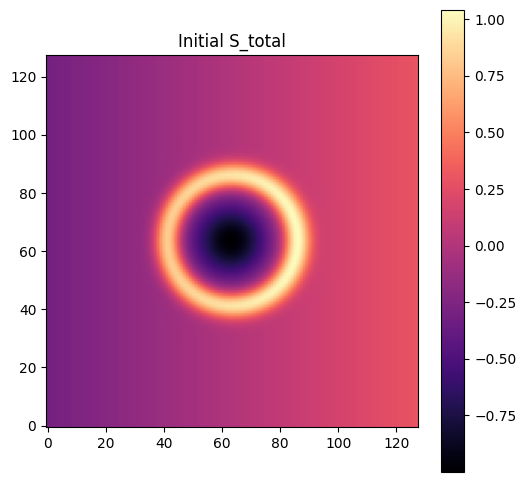

In [ ]:
# Initialize dynamic entropic field
S_dyn = np.zeros_like(S_env)

def compute_S_total(S_env, S_dyn):
    return S_env + S_dyn

S_total = compute_S_total(S_env, S_dyn)

plt.imshow(S_total.T, origin="lower")
plt.title("Initial S_total")
plt.colorbar()
plt.show()


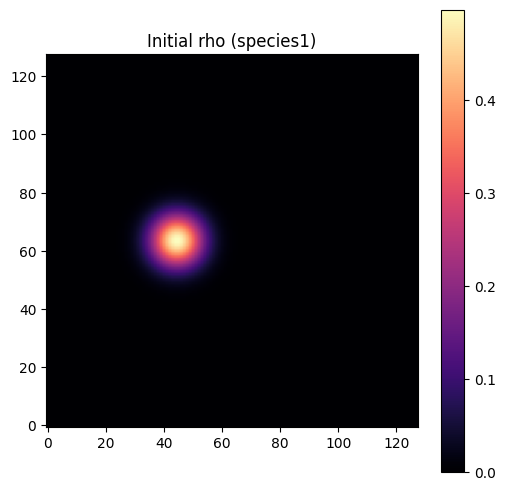

In [ ]:
from dataclasses import dataclass

@dataclass
class Species:
    name: str
    mass: float
    gamma: float
    kappa: float
    coupling: float

# Example: two species
species_list = [
    Species("species1", mass=1.0, gamma=5/3, kappa=1.0, coupling=1.0),
    Species("species2", mass=0.5, gamma=4/3, kappa=0.5, coupling=0.8),
]

ns = len(species_list)

# Species fields: rho, vx, vy
rho = np.zeros((ns, N, N))
vx  = np.zeros((ns, N, N))
vy  = np.zeros((ns, N, N))

# Simple initial condition: small Gaussian blobs
def init_species(rho, X, Y):
    for s in range(ns):
        cx = -0.3 + 0.3 * s
        cy = 0.0
        blob = np.exp(-((X - cx)**2 + (Y - cy)**2) / (2 * 0.1**2))
        rho[s] = 0.5 * blob
    return rho

rho = init_species(rho, X, Y)

plt.imshow(rho[0].T, origin="lower")
plt.title("Initial rho (species1)")
plt.colorbar()
plt.show()


In [ ]:
# --- Cell 7: EOS + gradients (no velocities) ---

max_rho = 1.0
min_rho = 1e-4

def compute_pressure(rho, species_list):
    P = np.zeros_like(rho)
    for s, sp in enumerate(species_list):
        gamma = min(sp.gamma, 1.2)  # soften EOS
        P[s] = sp.kappa * np.power(rho[s], gamma)
    return P

def grad2d(field):
    dfdx = np.gradient(field, axis=0)
    dfdy = np.gradient(field, axis=1)
    return dfdx, dfdy

def laplacian(field):
    return (
        -4 * field
        + np.roll(field, 1, axis=0)
        + np.roll(field, -1, axis=0)
        + np.roll(field, 1, axis=1)
        + np.roll(field, -1, axis=1)
    )


In [ ]:
# --- Cell 8: Drift + diffusion species update (no vx, vy) ---

species_diffusion = 0.001
species_drift     = 0.5   # strength of drift down ∇S_total

def update_species(rho, S_total, species_list, dt):
    ns, nx, ny = rho.shape

    P = compute_pressure(rho, species_list)
    dSdx, dSdy = grad2d(S_total)

    for s, sp in enumerate(species_list):
        # Drift flux: ρ * ( -∇S_total )
        drift_x = -species_drift * rho[s] * dSdx
        drift_y = -species_drift * rho[s] * dSdy

        ddriftdx = np.gradient(drift_x, axis=0)
        ddriftdy = np.gradient(drift_y, axis=1)

        # Diffusion term: D ∇²ρ
        diff_term = species_diffusion * laplacian(rho[s])

        # Update ρ
        drhodt = diff_term - (ddriftdx + ddriftdy)
        rho[s] += dt * drhodt

        # Keep ρ in a reasonable range
        rho[s] = np.clip(rho[s], min_rho, max_rho)

    return rho, P


In [ ]:
# --- Cell 9: S_dyn update with species source ---

curvature_strength = 0.01
diffusion_coeff    = 0.002
nonlinear_coeff    = 0.0   # keep off for now

def species_curvature_source(rho, P, species_list):
    src = np.zeros_like(rho[0])
    for s, sp in enumerate(species_list):
        src += sp.coupling * (rho[s] + P[s])
    return src

def update_S_dyn(S_dyn, S_env, rho, P, species_list, dt):
    S_total = S_env + S_dyn

    diff_term  = diffusion_coeff * laplacian(S_dyn)
    nonlin_term = nonlinear_coeff * (S_dyn**3)  # currently zero
    src        = species_curvature_source(rho, P, species_list)

    dSdt = diff_term + nonlin_term + curvature_strength * src

    S_dyn = S_dyn + dt * dSdt
    return S_dyn


step 0/4000


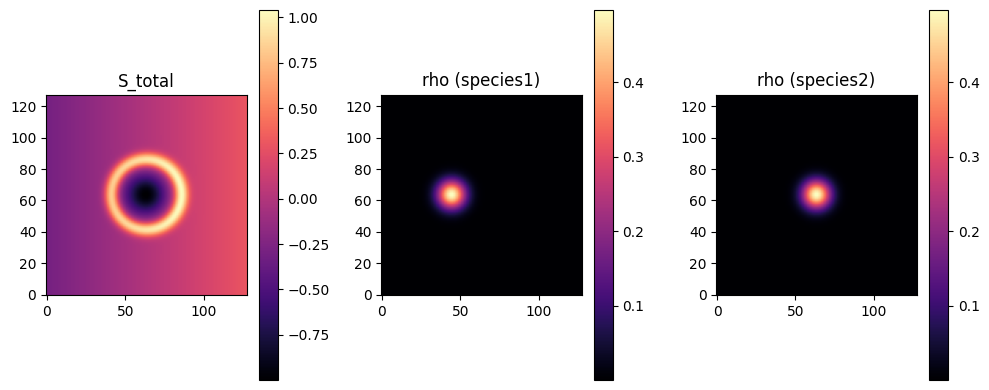

step 200/4000


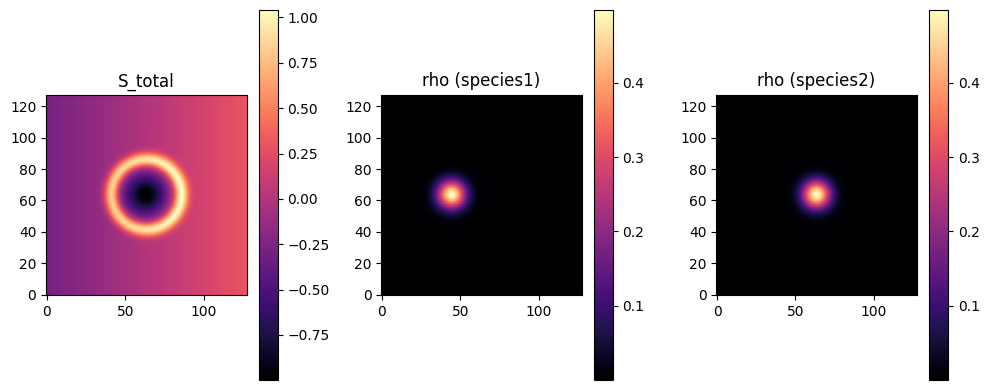

step 400/4000


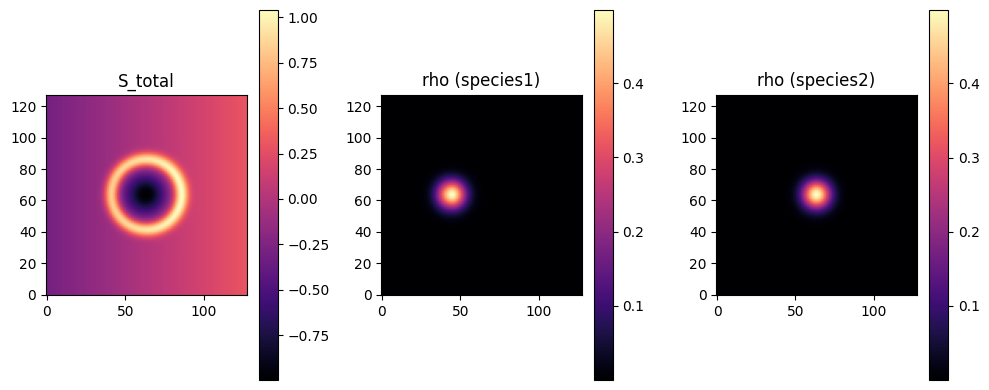

step 600/4000


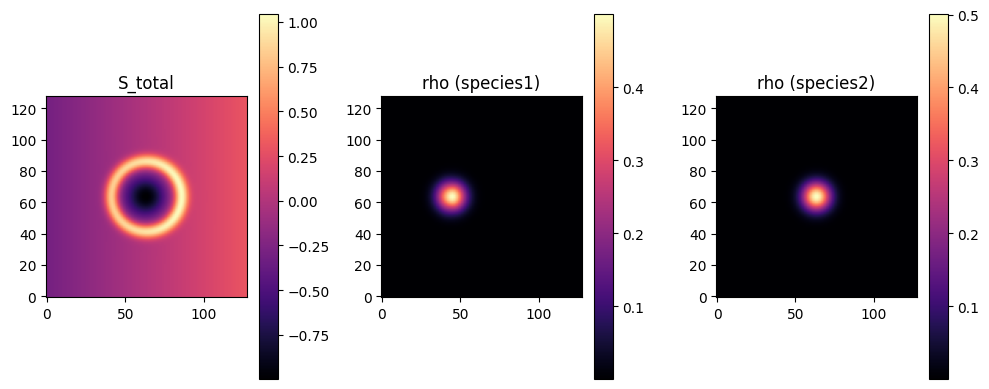

step 800/4000


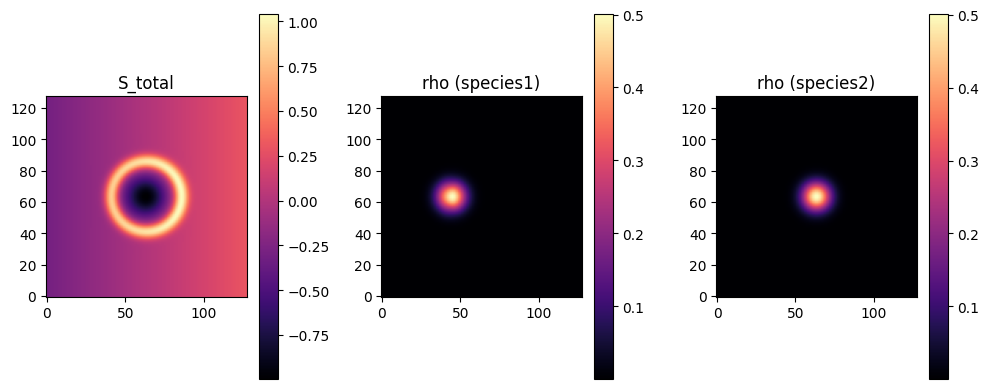

step 1000/4000


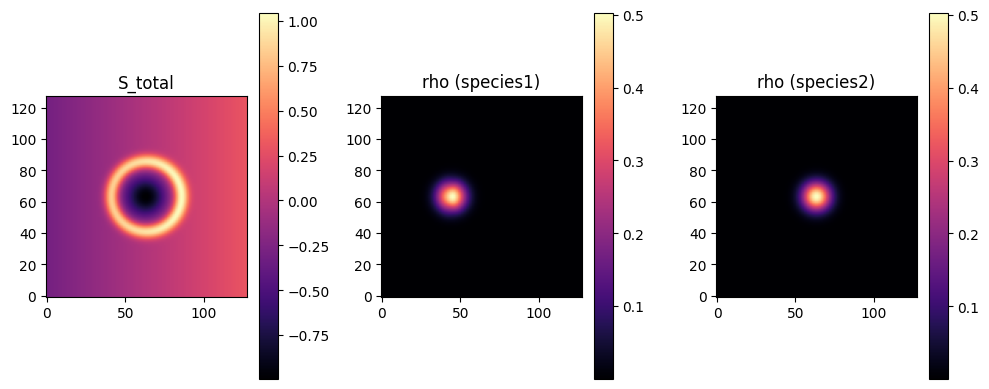

step 1200/4000


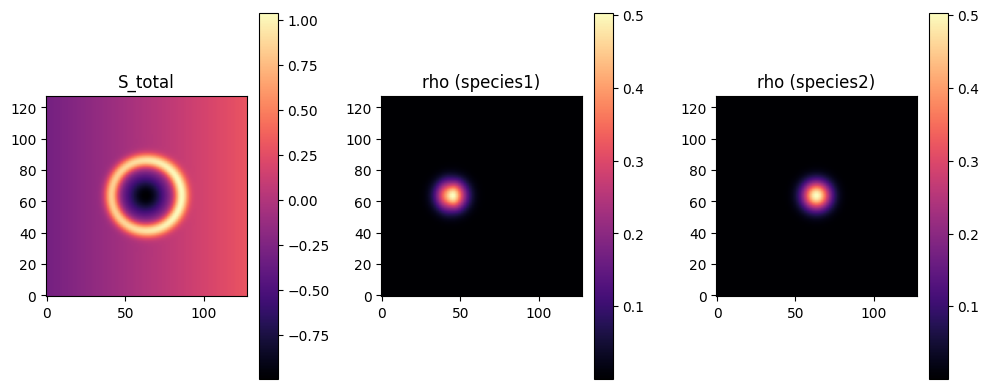

step 1400/4000


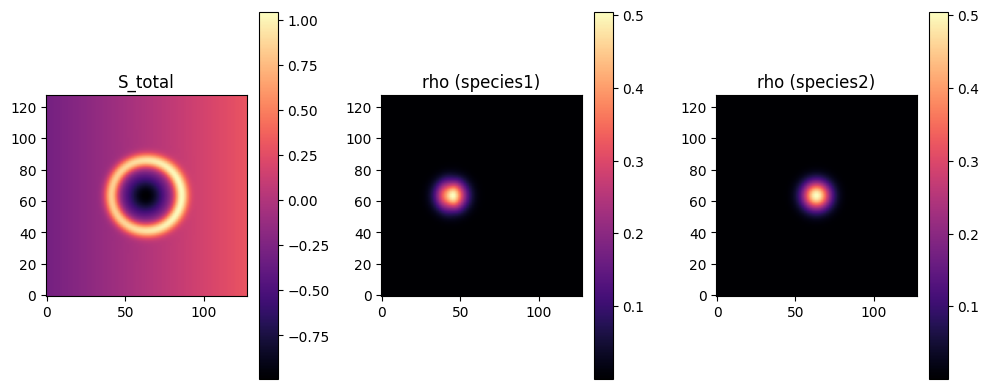

step 1600/4000


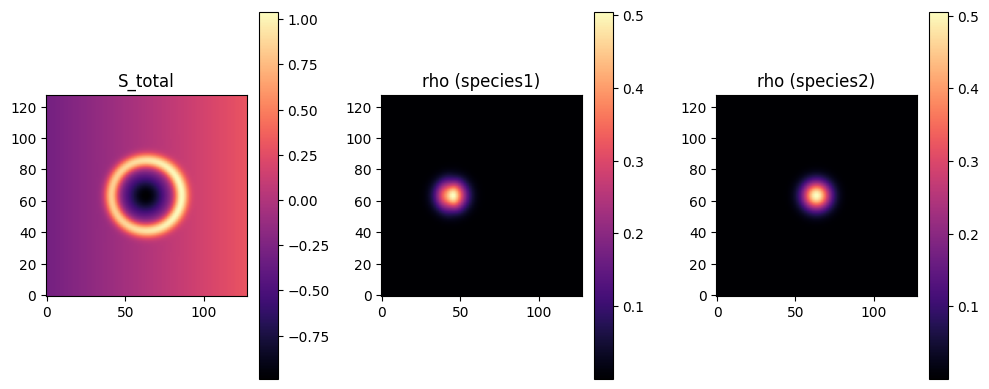

step 1800/4000


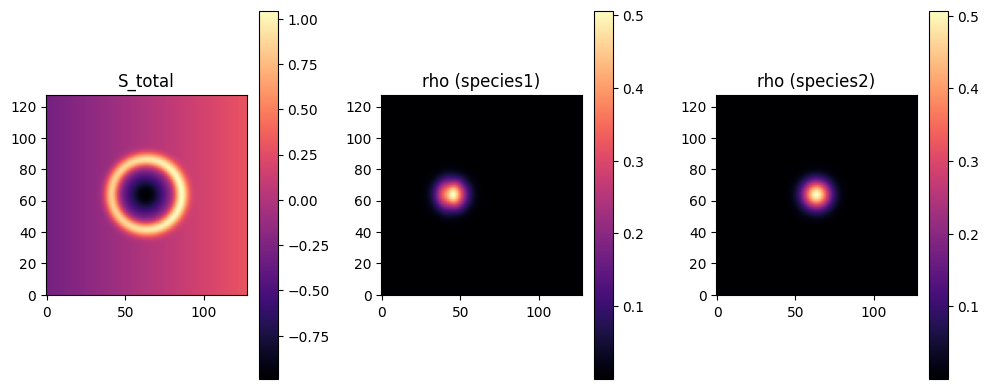

step 2000/4000


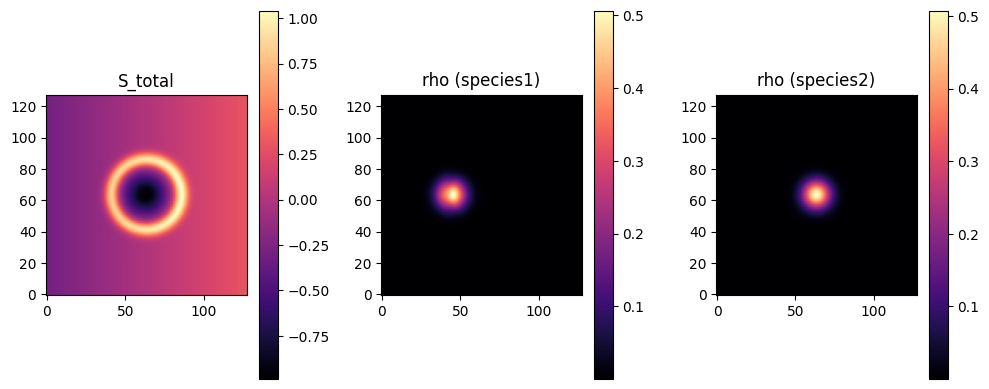

step 2200/4000


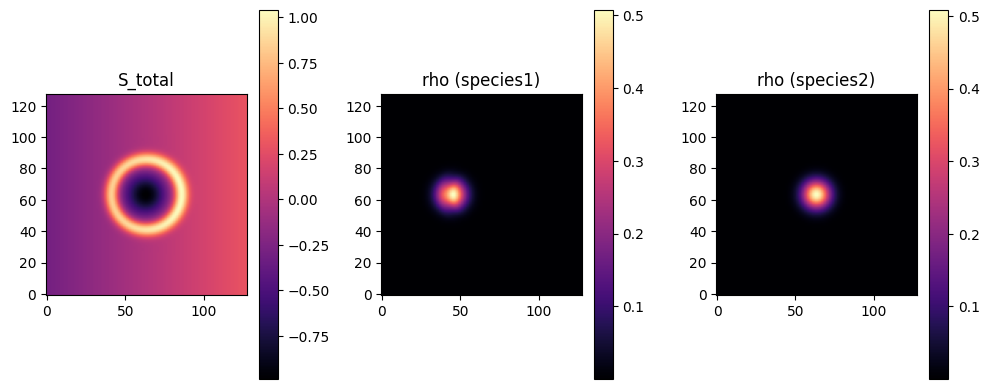

step 2400/4000


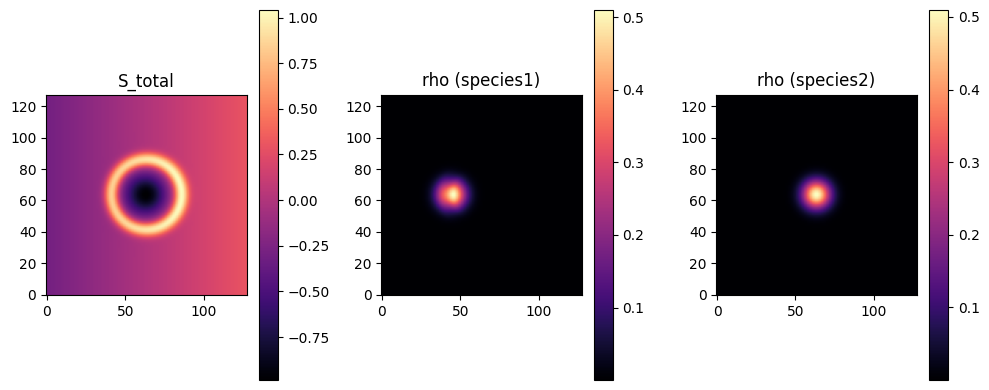

step 2600/4000


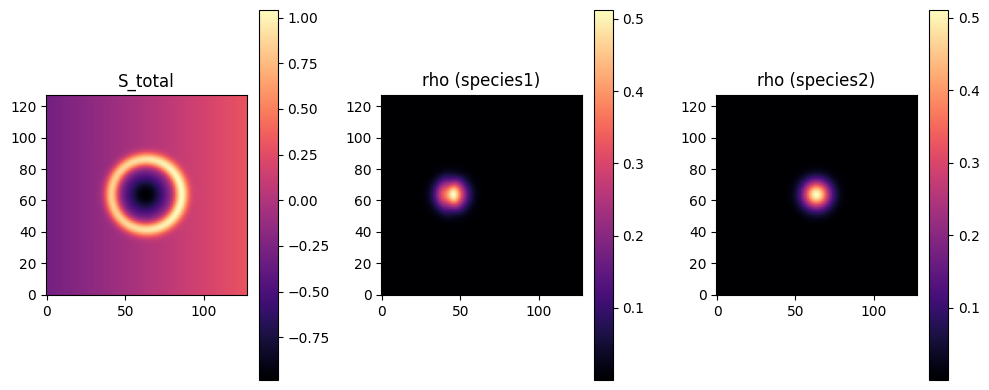

step 2800/4000


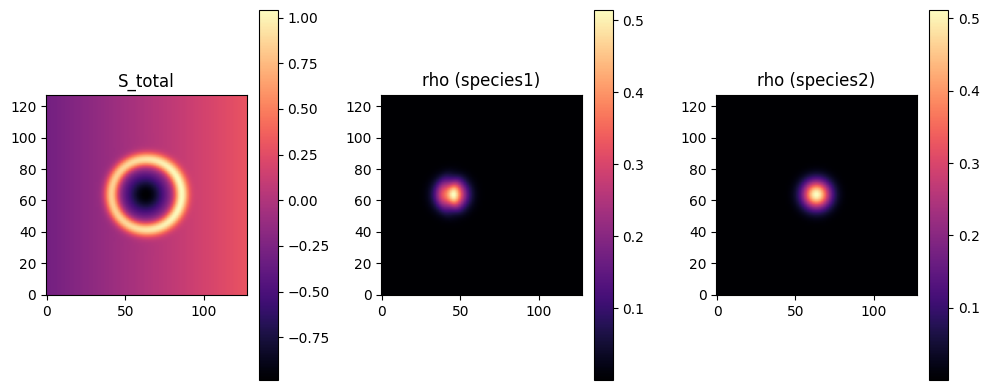

step 3000/4000


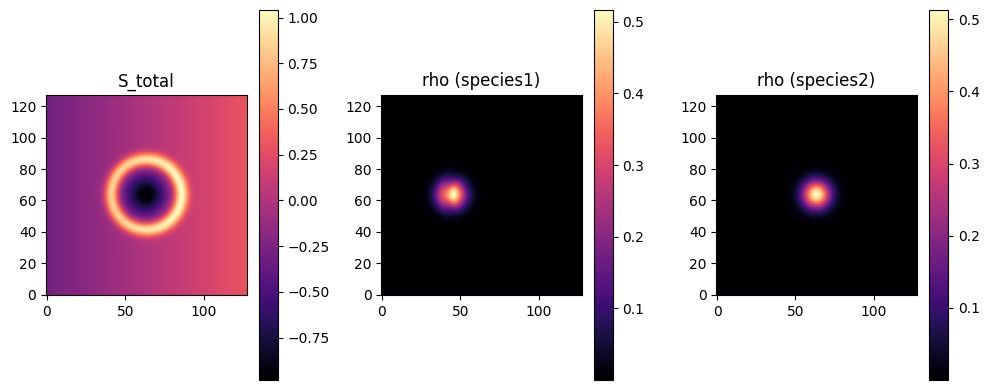

step 3200/4000


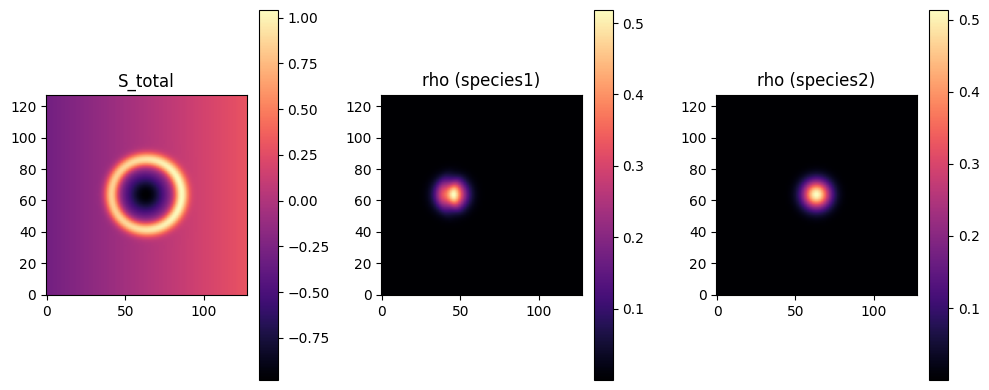

step 3400/4000


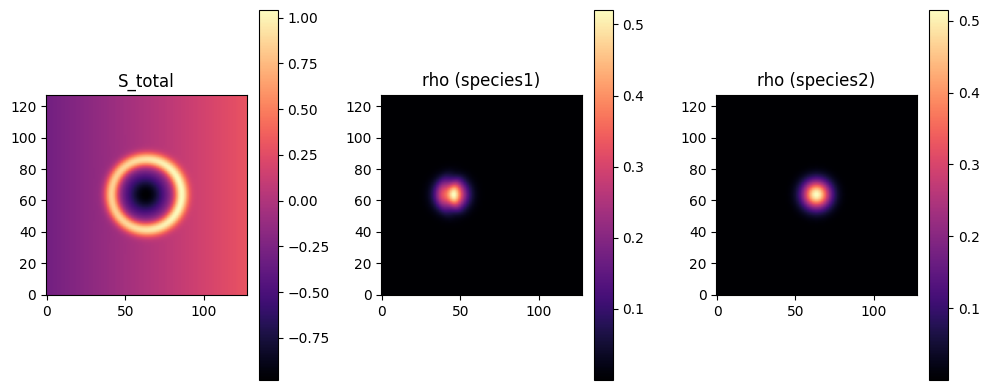

step 3600/4000


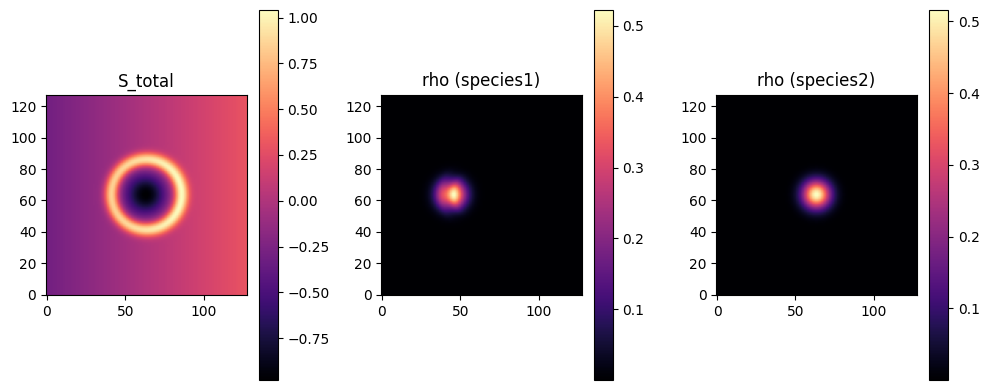

step 3800/4000


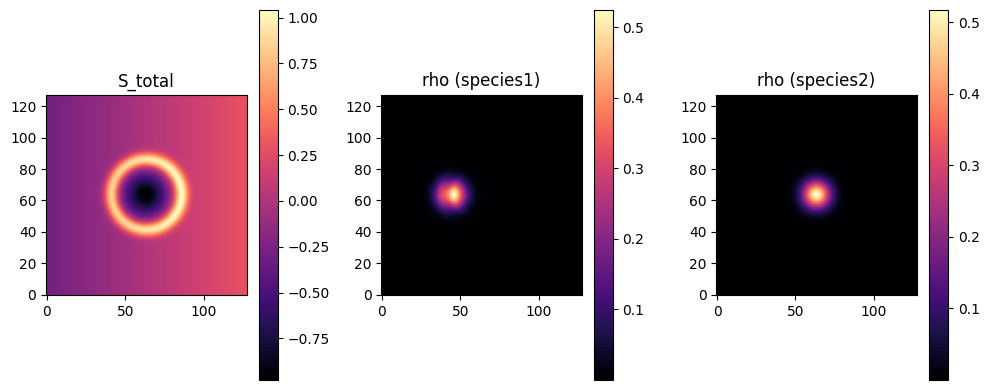

In [ ]:
# --- Cell 10: RK2 loop with drift+diffusion species ---

dt = 0.001
n_steps = 4000
output_every = 200

S_dyn = np.zeros_like(S_env)
S_total = S_env + S_dyn

for step in range(n_steps):

    # --- RK2 stage 1 ---
    rho1, P1 = update_species(rho.copy(), S_total, species_list, dt)
    S_dyn1   = update_S_dyn(S_dyn.copy(), S_env, rho1, P1, species_list, dt)
    S_total1 = S_env + S_dyn1

    # --- RK2 stage 2 ---
    rho2, P2 = update_species(rho.copy(), S_total1, species_list, dt)
    S_dyn2   = update_S_dyn(S_dyn.copy(), S_env, rho2, P2, species_list, dt)

    # Combine stages
    rho   = 0.5 * (rho1 + rho2)
    S_dyn = 0.5 * (S_dyn1 + S_dyn2)
    S_total = S_env + S_dyn

    if step % output_every == 0:
        print(f"step {step}/{n_steps}")

        plt.figure(figsize=(10, 4))

        plt.subplot(1, 3, 1)
        plt.imshow(S_total.T, origin="lower")
        plt.title("S_total")
        plt.colorbar()

        plt.subplot(1, 3, 2)
        plt.imshow(rho[0].T, origin="lower")
        plt.title("rho (species1)")
        plt.colorbar()

        plt.subplot(1, 3, 3)
        plt.imshow(rho[1].T, origin="lower")
        plt.title("rho (species2)")
        plt.colorbar()

        plt.tight_layout()
        plt.show()
